In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import sys
from models.custom_cnn import CustomCNN
import os

sys.path.append('..')
sys.path.append('../..')

from models.lenet import LeNet5
from shared.utils.trainer import train_one_epoch, validate

Matplotlib is building the font cache; this may take a moment.


In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


In [3]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_data = datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform_train)
test_data = datasets.CIFAR10(root='../../data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2)


100%|██████████| 170M/170M [00:24<00:00, 7.00MB/s] 


In [ ]:
lenet_model = LeNet5(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lenet_model.parameters(), lr=0.001)

In [ ]:
num_epochs = 20
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(lenet_model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = validate(lenet_model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {test_loss:.4f}, Val Acc: {test_acc:.2f}%")

Epoch 1/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.39it/s]


Train Loss: 1.6687, Train Acc: 38.90%
Val Loss: 1.4494, Val Acc: 47.38%
Epoch 2/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.44it/s]


Train Loss: 1.3808, Train Acc: 50.18%
Val Loss: 1.3382, Val Acc: 52.05%
Epoch 3/20


...

Train Loss: 0.7223, Train Acc: 74.42%
Val Loss: 1.0608, Val Acc: 65.46%
Epoch 19/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.41it/s]


Train Loss: 0.7021, Train Acc: 75.16%
Val Loss: 1.0924, Val Acc: 63.95%
Epoch 20/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.43it/s]

Train Loss: 0.6809, Train Acc: 76.00%
Val Loss: 1.1020, Val Acc: 64.27%


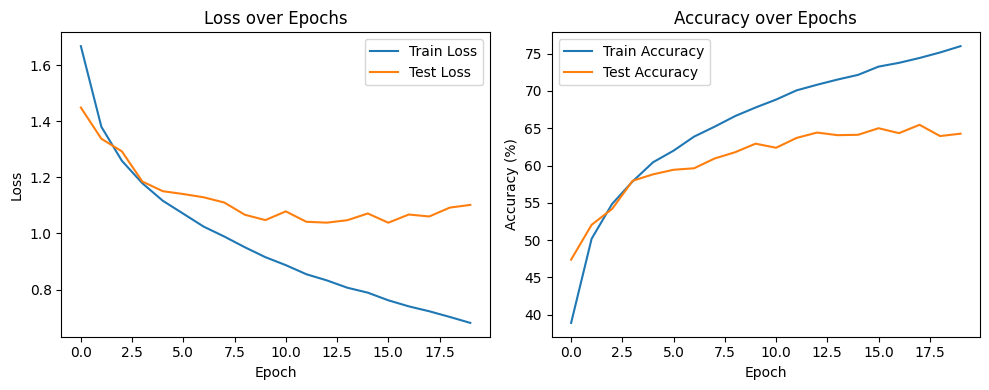

In [26]:
# Plot metrics and save the figure (saving in the same cell avoids blank images)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(test_losses, label='Test Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(test_accuracies, label='Test Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

fig.tight_layout()

os.makedirs('../results', exist_ok=True)
fig.savefig('../results/lenet_training.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
cnn_model = CustomCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

In [16]:
num_epochs = 20
cnn_train_losses, cnn_train_accuracies = [], []
cnn_test_losses, cnn_test_accuracies = [], []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = validate(cnn_model, test_loader, criterion, device)

    cnn_train_losses.append(train_loss)
    cnn_train_accuracies.append(train_acc)

    cnn_test_losses.append(test_loss)
    cnn_test_accuracies.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {test_loss:.4f}, Val Acc: {test_acc:.2f}%")

Epoch 1/20


Validation: 100%|██████████| 79/79 [00:13<00:00,  5.97it/s]


Train Loss: 1.5598, Train Acc: 43.10%
Val Loss: 1.2308, Val Acc: 56.54%
Epoch 2/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.09it/s]


Train Loss: 1.0687, Train Acc: 61.97%
Val Loss: 0.9077, Val Acc: 67.48%
Epoch 3/20


...

Train Loss: 0.0957, Train Acc: 96.81%
Val Loss: 0.6545, Val Acc: 83.80%
Epoch 19/20


Validation: 100%|██████████| 79/79 [00:13<00:00,  5.95it/s]


Train Loss: 0.0886, Train Acc: 97.02%
Val Loss: 0.6242, Val Acc: 86.17%
Epoch 20/20


Validation: 100%|██████████| 79/79 [00:13<00:00,  6.01it/s]

Train Loss: 0.0800, Train Acc: 97.31%
Val Loss: 0.6530, Val Acc: 86.32%


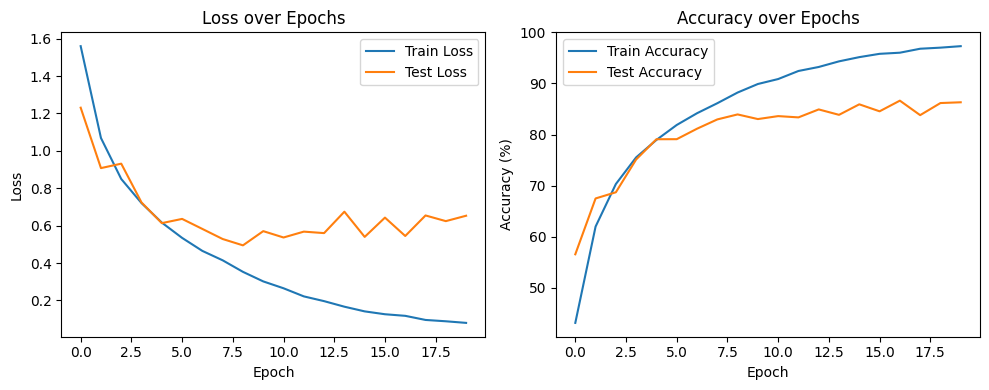

In [25]:
# Plot metrics and save the figure (saving in the same cell avoids blank images)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(cnn_train_losses, label='Train Loss')
ax1.plot(cnn_test_losses, label='Test Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(cnn_train_accuracies, label='Train Accuracy')
ax2.plot(cnn_test_accuracies, label='Test Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

fig.tight_layout()

os.makedirs('../results', exist_ok=True)
fig.savefig('../results/custom_cnn_training.png', dpi=300, bbox_inches='tight')
plt.show()

Predicted: cat, Actual: cat


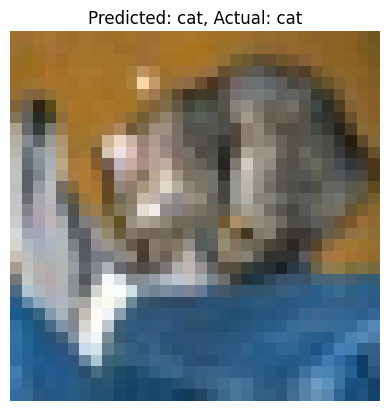

In [24]:
cnn_model.eval()
with torch.no_grad():
    image, label = test_data[0]
    image = image.unsqueeze(0).to(device)
    label = torch.tensor([label], device=device)

    outputs = cnn_model(image)
    _, predicted = torch.max(outputs, 1)

predicted_label_name = test_data.classes[predicted.item()]
actual_label_name = test_data.classes[label.item()]
print(f"Predicted: {predicted_label_name}, Actual: {actual_label_name}")

# showing image
img = image[0].cpu().numpy().transpose((1, 2, 0))
img = (img * [0.2470, 0.2435, 0.2616]) + [0.4914, 0.4822, 0.4465]  # unnormalize
img = img.clip(0, 1)
plt.imshow(img)
plt.title(f"Predicted: {predicted_label_name}, Actual: {actual_label_name}")
plt.axis('off')
plt.show()